In [4294]:
import numpy as np
import matplotlib.pyplot as plt

In [4295]:
TIME_RESOLUTION = 0.2


THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
CURVATURE = 1

In [4296]:
def create_pulse_train(basic_voltage, pulse_voltage, pulse_duration, interval_duration, pulse_quantity):
    train_length = (pulse_duration + interval_duration) * pulse_quantity

    pulse_train = np.zeros(train_length) + basic_voltage

    for i in range(pulse_quantity):
        pulse_train[i * (pulse_duration + interval_duration): (i * (pulse_duration + interval_duration)) + (pulse_duration)] = pulse_voltage
    
    return pulse_train

In [4297]:
def IGT_exponent(v, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    return np.exp(-((v - threshold_voltage) / scale_voltage) ** curvature)

def evolve_IGT(k, v, In_1, beta, tau):
    one_vector = np.ones_like(In_1)
    current_in_infinity = (k * (one_vector - IGT_exponent(v)))

    return current_in_infinity + (In_1 - current_in_infinity) * np.exp(-(TIME_RESOLUTION / tau) ** beta)

def plot_out_current(pulse_train, out_current, title):
    time = np.arange(len(out_current)) * TIME_RESOLUTION

    _, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(8, 5),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 3]}
    )

    # Pulse train
    ax1.step(time, pulse_train, where="post")
    ax1.set_ylabel("Pulse")
    ax1.set_title(title)
    ax1.grid(True)

    # Out Current
    ax2.plot(time, out_current)
    ax2.scatter(time, out_current, facecolors="none", edgecolors="tab:blue")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel(r"$I_{DS}\ (nA)$")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [4298]:
def current_to_voltage(current_in_infinity, k, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    return np.power(np.log(1/(1-(current_in_infinity/k))), 1/curvature) * scale_voltage + threshold_voltage

In [4299]:
BETA = 0.56
TAU = 2.6 #ms
K = 700 #nA

In [ ]:
neuron_number = 3

# input
input = np.concatenate((
    create_pulse_train(0, 2.5, 1, 1, 20),
    np.zeros(20),
    create_pulse_train(0, 2.5, 1, 4, 20),
    np.zeros(20)
))

time_space = np.linspace(0, 10, input.shape[0])*TIME_RESOLUTION

In [4301]:
# Input weights
weight_input = np.random.normal(-1, 1, size=(neuron_number, 1))

# Neurons' states
In = np.zeros((neuron_number, 1))

# Intern weights
weight_reservoir = np.random.normal(-1, 1, size=(neuron_number, neuron_number))

# Readout weights
weight_output = np.random.normal(-1, 1, size=(1, neuron_number))

true_readout = np.ones(neuron_number)

results = []
true_results = []
states = []
errors = []


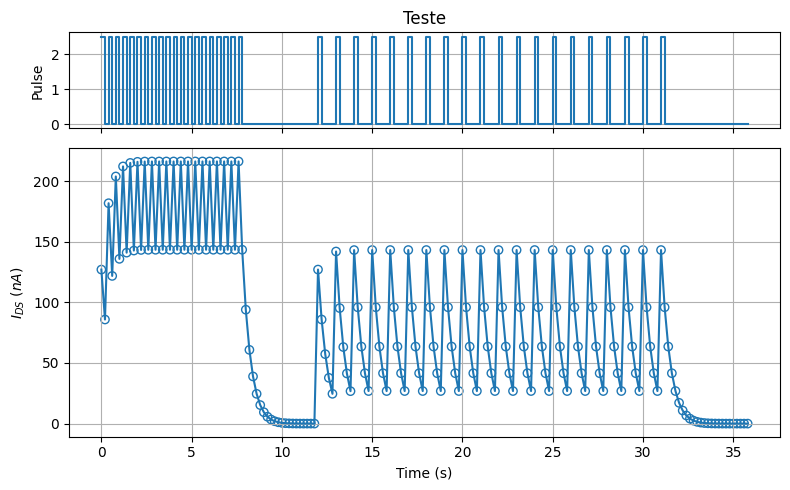

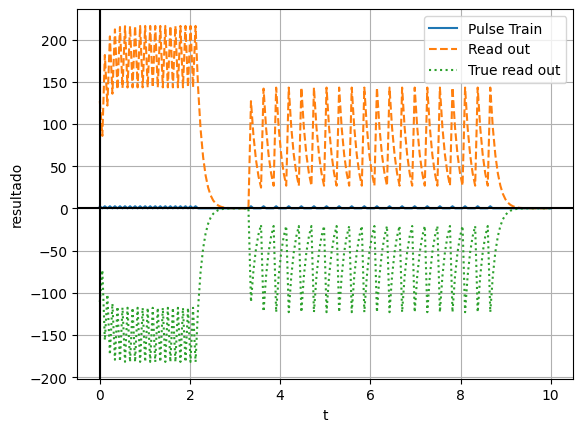

In [4302]:
for data in input:
    sum_matrix = np.ones_like(In) @ (np.ones_like(In).T @ abs(weight_reservoir))
    sum_matrix = (lambda x: 1/x)(sum_matrix)

    result_current = (sum_matrix*weight_reservoir) @ In


    # result_current[(result_current<0)]=0
    In = evolve_IGT(
        K, 
        current_to_voltage(result_current, K) + data*weight_input, 
        In, 
        BETA, 
        TAU
    )

    states.append(In.flatten())

    y = weight_output @ In.flatten()
    true_y = true_readout @ In.flatten()

    results.append(y)
    true_results.append(true_y)

# Erro 1
R = input - np.array(results)
erro = np.mean(R**2)

plot_out_current(input, results, "Teste")

plt.plot(time_space, input, label="Pulse Train")
plt.plot(time_space, results, label="Read out", linestyle="--")
plt.plot(time_space, true_results, label="True read out", linestyle=":")
plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.xlabel("t")
plt.ylabel("resultado")
plt.legend()
plt.grid()
plt.show()